In [147]:
import io
import os
import json
import pandas as pd
import numpy as np
from datetime import datetime as dt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.api as sm
import plotly.express as px
from IPython.display import HTML
from IPython.display import Image
import warnings
warnings.filterwarnings('ignore')

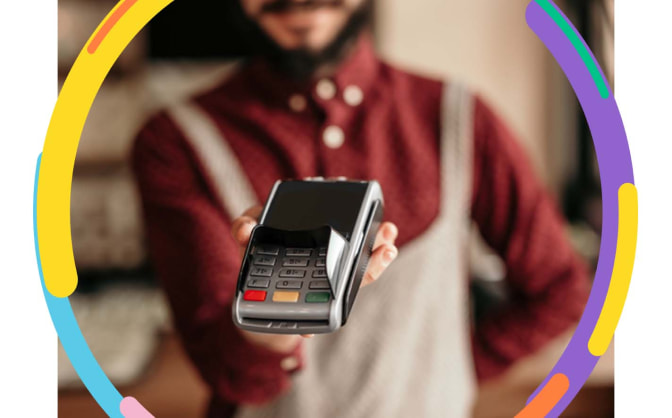

In [93]:
Image(filename = "img/datafono_fisico.jpg", width=1500, height=500)


# Introducción

In [148]:
df = pd.read_excel('main_data/evolucion_vinculacion_y_uso_adquirencia_1_a_1.xlsx', sheet_name='Sheet1', converters={'fecha_ymd2': pd.Timestamp})
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   periodo                     56 non-null     int64         
 1   fecha_ymd2                  56 non-null     datetime64[ns]
 2   num_vinc_new                56 non-null     int64         
 3   num_vinc_new_cumsum_ym      56 non-null     int64         
 4   num_vinc_new_cumsum         56 non-null     int64         
 5   num_vinc_old                56 non-null     int64         
 6   num_vinc_all                56 non-null     int64         
 7   num_vinc_new_uso_cumsum_ym  56 non-null     int64         
 8   num_vinc_old_uso_cumsum_ym  56 non-null     int64         
 9   num_vinc_all_uso_cumsum_ym  56 non-null     int64         
 10  num_vinc_new_prop_uso       56 non-null     float64       
 11  num_vinc_old_prop_uso       56 non-null     float64       
 

In [95]:
df

,periodo,fecha_ymd2,num_vinc_new,num_vinc_new_cumsum_ym,num_vinc_new_cumsum,num_vinc_old,num_vinc_all,num_vinc_new_uso_cumsum_ym,num_vinc_old_uso_cumsum_ym,num_vinc_all_uso_cumsum_ym,num_vinc_new_prop_uso,num_vinc_old_prop_uso,num_vinc_all_prop_uso
0,202608,2026-08-01,3648,27426,209157,447596,475018,13971,109803,123775,0.5094,0.2453,0.2606
1,202607,2026-07-01,3812,23778,205509,447611,471385,12093,109345,121439,0.5086,0.2443,0.2576
2,202606,2026-06-01,3107,19966,201697,447619,467583,10280,108755,119036,0.5149,0.2430,0.2546
3,202605,2026-05-01,3364,16859,198590,448057,464916,8447,108073,116521,0.5010,0.2412,0.2506
4,202604,2026-04-01,3739,13495,195226,448056,461551,6523,107059,113583,0.4834,0.2389,0.2461
5,202603,2026-03-01,3887,9756,191487,448074,457831,4602,105678,110281,0.4717,0.2358,0.2409
6,202602,2026-02-01,3200,5869,187600,448099,453969,2617,103470,106088,0.4459,0.2309,0.2337
7,202601,2026-01-01,2669,2669,184400,448103,450772,1004,98960,99964,0.3762,0.2208,0.2218
8,202512,2025-12-01,3412,38305,181731,409803,448104,24455,113080,137535,0.6384,0.2759,0.3069
9,202511,2025-11-01,3284,34893,178319,409832,444725,22119,112697,134816,0.6339,0.2750,0.3031


# Vinculaciones

In [96]:
df_plot1 = df[['fecha_ymd2', 'num_vinc_new_cumsum_ym']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ymd2', 'num_vinc_old']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ymd2', 'num_vinc_all']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

df_plot = pd.concat([df_plot3, df_plot2])
fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución Número de códigos únicos vinculados adquirencia 1 a 1 viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados adquirencia 1 a 1"
            ))
)
fig.add_annotation(x='2025-06-01', y=370000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.add_annotation(x='2025-12-01', y=448104,
            text="448.104",
            showarrow=True,
            arrowhead=1)
fig.show()

In [97]:
df_plot = pd.concat([df_plot1])
fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución Número de códigos únicos vinculados adquirencia 1 a 1 nuevos",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados adquirencia 1 a 1"
            ))
)
fig.add_annotation(x='2025-06-01', y=40000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

# Uso

In [98]:
df_plot1 = df[['fecha_ymd2', 'num_vinc_new_uso_cumsum_ym']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ymd2', 'num_vinc_old_uso_cumsum_ym']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ymd2', 'num_vinc_all_uso_cumsum_ym']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

df_plot = pd.concat([df_plot2, df_plot3])

fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución número de códigos únicos vinculados adquirencia 1 a 1 recibiendo al menos 1 transacción [año acumulado] viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados adquirencia 1 a 1"
            ))
)
fig.add_annotation(x='2025-06-01', y=140000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=142097,
#             text="142.097",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=103274,
#             text="103.274",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=38823,
#             text="38.823",
#             showarrow=True,
#             arrowhead=1)
fig.show()

In [99]:
df_plot1 = df[['fecha_ymd2', 'num_vinc_new_uso_cumsum_ym']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ymd2', 'num_vinc_old_uso_cumsum_ym']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ymd2', 'num_vinc_all_uso_cumsum_ym']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

df_plot = pd.concat([df_plot1])

fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución número de códigos únicos vinculados adquirencia 1 a 1 recibiendo al menos 1 transacción [año acumulado] nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados adquirencia 1 a 1"
            ))
)
fig.add_annotation(x='2025-06-01', y=30000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=142097,
#             text="142.097",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=103274,
#             text="103.274",
#             showarrow=True,
#             arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=38823,
#             text="38.823",
#             showarrow=True,
#             arrowhead=1)
fig.show()

# Proporción uso

In [100]:
df_plot1 = df[['fecha_ymd2', 'num_vinc_new_prop_uso']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ymd2', 'num_vinc_old_prop_uso']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ymd2', 'num_vinc_all_prop_uso']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

df_plot = pd.concat([df_plot1[:35], df_plot2[:35], df_plot3[:35]])
df_plot = pd.concat([df_plot1, df_plot2, df_plot3])

fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución proporción de códigos únicos vinculados adquirencia 1 a 1 realizando al menos 1 transacción [año acumulado] por nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Proporción de códigos únicos vinculados adquirencia 1 a 1"
            ))
)
fig.add_annotation(x='2025-06-01', y=0.48,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
# fig.add_annotation(x='2025-11-01', y=0.3347,
#             text="0,3347",
#             showarrow=False,
#             yshift=10)
# fig.add_annotation(x='2025-11-01', y=0.319,
#             text="0,319",
#             showarrow=False,
#             yshift=10)
# fig.add_annotation(x='2025-11-01', y=0.3852,
#             text="0,3852",
#             showarrow=False,
#             yshift=10)
fig.show()

# Cifras en perspectiva histórica, metas y proyecciones

In [101]:
df_plot1 = df[['fecha_ymd2', 'num_vinc_new_uso_cumsum_ym']]
df_plot1.columns = ['fecha', 'cantidad_clientes']
df_plot1['clientes'] = 'nuevos'
df_plot2 = df[['fecha_ymd2', 'num_vinc_old_uso_cumsum_ym']]
df_plot2.columns = ['fecha', 'cantidad_clientes']
df_plot2['clientes'] = 'viejos'
df_plot3 = df[['fecha_ymd2', 'num_vinc_all_uso_cumsum_ym']]
df_plot3.columns = ['fecha', 'cantidad_clientes']
df_plot3['clientes'] = 'totales'

# df_plot = pd.concat([df_plot1[:35], df_plot2[:35], df_plot3[:35]])
df_plot = pd.concat([df_plot1, df_plot2, df_plot3])

fig = px.line(df_plot, x="fecha", y="cantidad_clientes", color='clientes',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución códigos únicos vinculados adquirencia 1 a 1 recibiendo al menos 1 transacción [año acumulado] nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados adquirencia 1 a 1"
            ))
)
fig.add_annotation(x='2025-06-01', y=70000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.add_annotation(x='2026-03-01', y=110281,
            text="110.281",
            showarrow=False,
            yshift=10)
fig.add_annotation(x='2024-12-01', y=150475,
            text="<b>150.475</b><br>Base 2024",
            yshift=10,
            font=dict(
            family="Courier New, monospace",
            size=20,
            color="#E60505"
            ))
fig.add_annotation(x='2025-12-01', y=137535,
            text="<b>137.535</b><br>Base 2025",
            yshift=10,
            font=dict(
            family="Courier New, monospace",
            size=20,
            color="#E60505"
            ))
fig.add_annotation(x='2026-03-01', y=105678,
            text="105.678",
            showarrow=False,
            yshift=-19)
fig.add_annotation(x='2026-03-01', y=4602,
            text="4.602",
            showarrow=True,
            arrowhead=1)
fig.show()

# Proyecciones

No se hace proyección con un modelo para crearla sobre las imagenes cuando se haga la presentación. Es una forma de presentar que deseo explorar, realizar la proyección con la herramienta de lapiz que tienen las herramientas de presentación.

En el futuro se puede crear proyección con modelo heurístico o modelo estadístico.

## Vinculaciones

In [102]:
# Crear periodo de tiempo
meta = 58442
index_date = pd.date_range(start='2026-01-01', end='2026-12-31', freq='MS')
# index_date = pd.to_datetime(['2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18'])
df_periodo_2 = pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_periodo_2.columns = ['fecha', 'periodo_2']
df_periodo_2['valor'] = meta/12
df_periodo_2['valor'] = df_periodo_2['valor'].cumsum()
df_periodo_2['tipo_valor'] = 'metal_proyectada'
df_data = df[['fecha_ymd2', 'num_vinc_new_cumsum_ym']]
df_data.columns = ['fecha', 'valor']

df_data['tipo_valor'] = 'real'
df_plot = pd.concat([df_data, df_periodo_2]).reset_index(drop=True)
df_plot

,fecha,valor,tipo_valor,periodo_2
0,2026-08-01,27426.000000,real,NaN
1,2026-07-01,23778.000000,real,NaN
2,2026-06-01,19966.000000,real,NaN
3,2026-05-01,16859.000000,real,NaN
4,2026-04-01,13495.000000,real,NaN
...,...,...,...,...
63,2026-08-01,38961.333333,metal_proyectada,1.0
64,2026-09-01,43831.500000,metal_proyectada,1.0
65,2026-10-01,48701.666667,metal_proyectada,1.0
66,2026-11-01,53571.833333,metal_proyectada,1.0


In [105]:
fig = px.line(df_plot, x="fecha", y="valor", color='tipo_valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución vinculación mensual códigos únicos nuevos, y meta proyectada<br>Adquirencia 1 a 1<br>Acumulado año corrido",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos nuevos vinculados<br>acumulados año corrido<br>adquirencia 1 a 1"
            ))
)

fig.update_yaxes(visible=False)
fig.add_annotation(x='2025-06-01', y=45000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

fig.add_annotation(x='2026-12-01', y=58452,
            text="Meta proyectada<br><b>58.442</b> códigos únicos nuevos vinculados<br>acumulados en diciembre 2026",
            showarrow=False,
            xanchor='right')
fig.add_annotation(x='2026-08-01', y=38961,
            text="Meta proyectada<br><b>38.961</b> códigos únicos nuevos vinculados<br>acumulados hasta agosto 2026",
            showarrow=False,
            xanchor='left',
            xshift=3,
            yshift=25)
fig.add_annotation(x='2026-08-01', y=27426,
            text="Dato real<br><b>27.426</b> códigos únicos nuevos vinculados<br>acumulados hasta agosto 2026<br><b>29,6% por debajo de la meta proyectada</b>",
            showarrow=False,
            xanchor='left',
            xshift=3)


fig.show()

## Uso

### Viejos

In [149]:
# Crear periodo de tiempo
index_date = pd.date_range(start='2026-01-01', end='2026-12-31', freq='MS')
# index_date = pd.to_datetime(['2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18'])
df_periodo_2 = pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_periodo_2.columns = ['fecha', 'periodo_2']
df_periodo_2['valor'] = 0
df_periodo_2['valor'][0] = 98960
# df_periodo_2['valor'] = df_periodo_2['meta_lineal_1'].cumsum()
df_periodo_2 = df_periodo_2[['fecha', 'valor']]
df_periodo_2['tipo_valor'] = 'meta_proyectada'


# Crecimiento en 2026 para lograr objetivo replicando el crecimiento mensual de 2025 partiendo del valor real de enero de 2026
df_data_2025 = df_data[(df_data['fecha'] >= pd.to_datetime('2025-01-01') ) & (df_data['fecha'] <= pd.to_datetime('2025-12-01'))].sort_values('fecha')
crecimiento_2025 = df_data_2025.valor.diff()[1:].reset_index(drop=True).div(df_data_2025.valor[:-1].reset_index(drop=True)).round(4)
crecimiento_2025.index = range(1, 12)
df_periodo_2['crecimiento_para_lograr_objetivo'] = crecimiento_2025 # Para repartir los 33.956 que hacen falta para lograr 139.916 en diciembre 2026
df_periodo_2['crecimiento_para_lograr_objetivo'][0] = 0
df_periodo_2['crecimiento_para_lograr_objetivo'] = df_periodo_2.crecimiento_para_lograr_objetivo.div(df_periodo_2.crecimiento_para_lograr_objetivo.sum())


list_meta_2026 = []
for enu, (valor, crecimiento_objetivo) in enumerate(zip(df_periodo_2['valor'], df_periodo_2['crecimiento_para_lograr_objetivo'])):
    if enu == 0:
        list_meta_2026.append(98960)
    else:
        list_meta_2026.append(round((list_meta_2026[-1] + 32284 * (crecimiento_objetivo)), 0))
df_periodo_2['valor'] = list_meta_2026


df_data = df[['fecha_ymd2', 'num_vinc_old_uso_cumsum_ym']]
df_data.columns = ['fecha', 'valor']

df_data['tipo_valor'] = 'real'
df_plot = pd.concat([df_data, df_periodo_2]).reset_index(drop=True)
df_plot



,fecha,valor,tipo_valor,crecimiento_para_lograr_objetivo
0,2026-08-01,109803.0,real,NaN
1,2026-07-01,109345.0,real,NaN
2,2026-06-01,108755.0,real,NaN
3,2026-05-01,108073.0,real,NaN
4,2026-04-01,107059.0,real,NaN
...,...,...,...,...
63,2026-08-01,123104.0,meta_proyectada,0.064445
64,2026-09-01,125256.0,meta_proyectada,0.066646
65,2026-10-01,127387.0,meta_proyectada,0.066017
66,2026-11-01,129194.0,meta_proyectada,0.055957


In [152]:
fig = px.line(df_plot, x="fecha", y="valor", color='tipo_valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': 'Evolución mensual códigos únicos viejos con uso, y meta proyectada<br>Adquirencia 1 a 1<br>Acumulado año corrido<br>Uso: Al menos 1 transacción en el año corrido',
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos viejos con uso<br>acumulados año corrido<br>adquirencia 1 a 1"
            ))
)
fig.update_yaxes(visible=False)
fig.add_annotation(x='2025-06-01', y=125000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

fig.add_annotation(x='2026-12-01', y=131244,
            text="Meta proyectada<br><b>131.244</b> códigos únicos viejos con uso<br>acumulados en diciembre 2026",
            showarrow=False,
            xanchor='auto')
fig.add_annotation(x='2026-08-01', y=123104,
            text="Meta proyectada<br><b>123.104</b> códigos únicos viejos con uso<br>acumulados en agosto 2026",
            showarrow=False,
            xanchor='left',
            xshift=3)
fig.add_annotation(x='2026-08-01', y=109803,
            text="Dato real<br><b>109.803</b> códigos únicos viejos con uso<br>acumulados hasta agosto 2026.<br><b>10,8% por debajo de la meta proyectada</b>",
            showarrow=False,
            xanchor='left',
            xshift=3,
            yshift=45)
fig.show()

In [73]:
21658+109586

131244

In [431]:
10270/115948

0.08857418842929589

### Nuevos

In [153]:
# Crear periodo de tiempo
meta = 49363
index_date = pd.date_range(start='2026-01-01', end='2026-12-31', freq='MS')
# index_date = pd.to_datetime(['2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18'])
df_periodo_2 = pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_periodo_2.columns = ['fecha', 'periodo_2']
df_periodo_2['valor'] = meta/12
df_periodo_2['valor'] = df_periodo_2['valor'].cumsum()
df_periodo_2['tipo_valor'] = 'metal_proyectada'
df_data = df[['fecha_ymd2', 'num_vinc_new_uso_cumsum_ym']]
df_data.columns = ['fecha', 'valor']

df_data['tipo_valor'] = 'real'
df_plot = pd.concat([df_data, df_periodo_2]).reset_index(drop=True)
df_plot

,fecha,valor,tipo_valor,periodo_2
0,2026-08-01,13971.000000,real,NaN
1,2026-07-01,12093.000000,real,NaN
2,2026-06-01,10280.000000,real,NaN
3,2026-05-01,8447.000000,real,NaN
4,2026-04-01,6523.000000,real,NaN
...,...,...,...,...
63,2026-08-01,32908.666667,metal_proyectada,1.0
64,2026-09-01,37022.250000,metal_proyectada,1.0
65,2026-10-01,41135.833333,metal_proyectada,1.0
66,2026-11-01,45249.416667,metal_proyectada,1.0


In [156]:
fig = px.line(df_plot, x="fecha", y="valor", color='tipo_valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': 'Evolución mensual códigos únicos nuevos con uso, y meta proyectada<br>Adquirencia 1 a 1<br>Acumulado año corrido<br>Uso: Al menos 1 transacción en el año corrido',
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos nuevos con uso<br>acumulados año corrido<br>adquirencia 1 a 1"
            ))
)
fig.update_yaxes(visible=False)
fig.add_annotation(x='2025-06-01', y=32000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

fig.add_annotation(x='2026-12-01', y=49363,
            text="Meta proyectada<br><b>49.363</b> códigos únicos nuevos con uso<br>acumulados en diciembre 2026",
            showarrow=False,
            xanchor='right')
fig.add_annotation(x='2026-08-01', y=32908,
            text="Meta proyectada<br><b>32.908</b> códigos únicos nuevos con uso<br>acumulados en agosto 2026",
            showarrow=False,
            xanchor='left',
            xshift=3)
fig.add_annotation(x='2026-08-01', y=13971,
            text="Dato real<br><b>13.971</b> códigos únicos nuevos con uso<br>acumulados hasta agosto 2026.<br><b>42,5% por debajo de la meta proyectada</b>",
            showarrow=False,
            xanchor='left',
            xshift=3,
            yshift=25)

fig.show()

### Todos

In [106]:
# Crear periodo de tiempo
index_date = pd.date_range(start='2026-01-01', end='2026-12-31', freq='MS')
# index_date = pd.to_datetime(['2025-01-01', '2025-01-06', '2025-03-24', '2025-04-17', '2025-04-18'])
df_periodo_2 = pd.Series([1 for v in range(len(index_date))], index=index_date).reset_index()
df_periodo_2.columns = ['fecha', 'periodo_2']
df_periodo_2['valor'] = 0
df_periodo_2['valor'][0] = 99964
# df_periodo_2['valor'] = df_periodo_2['meta_lineal_1'].cumsum()
df_periodo_2 = df_periodo_2[['fecha', 'valor']]
df_periodo_2['tipo_valor'] = 'meta_proyectada'


# Crecimiento en 2026 para lograr objetivo replicando el crecimiento mensual de 2025 partiendo del valor real de enero de 2026
df_data_2025 = df_data[(df_data['fecha'] >= pd.to_datetime('2025-01-01') ) & (df_data['fecha'] <= pd.to_datetime('2025-12-01'))].sort_values('fecha')
crecimiento_2025 = df_data_2025.valor.diff()[1:].reset_index(drop=True).div(df_data_2025.valor[:-1].reset_index(drop=True)).round(4)
crecimiento_2025.index = range(1, 12)
df_periodo_2['crecimiento_para_lograr_objetivo'] = crecimiento_2025 # Para repartir los 76.977 que hacen falta para lograr 139.916 en diciembre 2026
df_periodo_2['crecimiento_para_lograr_objetivo'][0] = 0
df_periodo_2['crecimiento_para_lograr_objetivo'] = df_periodo_2.crecimiento_para_lograr_objetivo.div(df_periodo_2.crecimiento_para_lograr_objetivo.sum())


list_meta_2026 = []
for enu, (valor, crecimiento_objetivo) in enumerate(zip(df_periodo_2['valor'], df_periodo_2['crecimiento_para_lograr_objetivo'])):
    if enu == 0:
        list_meta_2026.append(99964)
    else:
        list_meta_2026.append(round((list_meta_2026[-1] + 80643 * (crecimiento_objetivo)), 0))
df_periodo_2['valor'] = list_meta_2026


df_data = df[['fecha_ymd2', 'num_vinc_all_uso_cumsum_ym']]
df_data.columns = ['fecha', 'valor']

df_data['tipo_valor'] = 'real'
df_plot = pd.concat([df_data, df_periodo_2]).reset_index(drop=True)
df_plot



,fecha,valor,tipo_valor,crecimiento_para_lograr_objetivo
0,2026-08-01,123775.0,real,NaN
1,2026-07-01,121439.0,real,NaN
2,2026-06-01,119036.0,real,NaN
3,2026-05-01,116521.0,real,NaN
4,2026-04-01,113583.0,real,NaN
...,...,...,...,...
63,2026-08-01,169512.0,meta_proyectada,0.039486
64,2026-09-01,172938.0,meta_proyectada,0.042480
65,2026-10-01,176013.0,meta_proyectada,0.038130
66,2026-11-01,178380.0,meta_proyectada,0.029346


In [110]:
fig = px.line(df_plot, x="fecha", y="valor", color='tipo_valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': 'Evolución mensual códigos únicos totales con uso, y meta proyectada<br>Adquirencia 1 a 1<br>Acumulado año corrido<br>Uso: Al menos 1 transacción en el año corrido',
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos totales con uso<br>acumulados año corrido<br>adquirencia 1 a 1"
            ))
)
fig.update_yaxes(visible=False)
fig.add_annotation(x='2025-06-01', y=150000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)

fig.add_annotation(x='2026-12-01', y=180608,
            text="Meta proyectada<br><b>180.608</b> códigos únicos totales con uso<br>acumulados en diciembre 2026",
            showarrow=False,
            yshift=30)
fig.add_annotation(x='2026-08-01', y=169512,
            text="Meta proyectada<br><b>169.512</b> códigos únicos totales con uso<br>acumulados en agosto 2026",
            showarrow=False,
            xanchor='left',
            xshift=3)
fig.add_annotation(x='2026-08-01', y=123775,
            text="Dato real<br><b>123.775</b> códigos únicos totales con uso<br>acumulados hasta agosto 2026.<br><b>27% por debajo de la meta proyectada</b>",
            showarrow=False,
            xanchor='left',
            xshift=3)

fig.show()

In [356]:
125083-110281

14802

In [357]:
14802/125083

0.11833742395049687

# Contribución

## Vinculaciones

In [111]:
df

,periodo,fecha_ymd2,num_vinc_new,num_vinc_new_cumsum_ym,num_vinc_new_cumsum,num_vinc_old,num_vinc_all,num_vinc_new_uso_cumsum_ym,num_vinc_old_uso_cumsum_ym,num_vinc_all_uso_cumsum_ym,num_vinc_new_prop_uso,num_vinc_old_prop_uso,num_vinc_all_prop_uso
0,202608,2026-08-01,3648,27426,209157,447596,475018,13971,109803,123775,0.5094,0.2453,0.2606
1,202607,2026-07-01,3812,23778,205509,447611,471385,12093,109345,121439,0.5086,0.2443,0.2576
2,202606,2026-06-01,3107,19966,201697,447619,467583,10280,108755,119036,0.5149,0.2430,0.2546
3,202605,2026-05-01,3364,16859,198590,448057,464916,8447,108073,116521,0.5010,0.2412,0.2506
4,202604,2026-04-01,3739,13495,195226,448056,461551,6523,107059,113583,0.4834,0.2389,0.2461
5,202603,2026-03-01,3887,9756,191487,448074,457831,4602,105678,110281,0.4717,0.2358,0.2409
6,202602,2026-02-01,3200,5869,187600,448099,453969,2617,103470,106088,0.4459,0.2309,0.2337
7,202601,2026-01-01,2669,2669,184400,448103,450772,1004,98960,99964,0.3762,0.2208,0.2218
8,202512,2025-12-01,3412,38305,181731,409803,448104,24455,113080,137535,0.6384,0.2759,0.3069
9,202511,2025-11-01,3284,34893,178319,409832,444725,22119,112697,134816,0.6339,0.2750,0.3031


In [112]:

df_plot3 = df[['fecha_ymd2', 'num_vinc_new']]
df_plot3.columns = ['fecha', 'cantidad_clientes']

df_plot = df_plot3

fig = px.line(df_plot, x="fecha", y="cantidad_clientes",markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución número de vinculaciones por clientes nuevos, viejos y totales",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes"
            ))
)
fig.add_annotation(x='2025-06-01', y=3000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.show()

## Ajustar modelos

In [113]:
# Selección variable
df_model = df[['fecha_ymd2', 'num_vinc_new_cumsum_ym']]
df_model.columns = ['fecha', 'num_vinc']
df_model.sort_values(by='fecha', inplace=True)

# Agregar variables
# Tendencia
df_model['tendencia'] = [i + 1 for i in range(len(df_model))]

# Tendencia cuadrática
df_model['tendencia_cuadratica'] = df_model['tendencia'] ** 2

# Tendencia cúbica
df_model['tendencia_cubica'] = df_model['tendencia'] ** 3

# Inicio campana
# index_date = pd.to_datetime(['2025-06-01', '2025-07-01'])
index_date = pd.date_range(start='2025-06-01', end='2026-07-31', freq='MS')
df_campana= pd.Series(['1' for v in range(len(index_date))], index=index_date).reset_index()
df_campana.columns = ['fecha', 'campana']
df_model = df_model.merge(df_campana, how='left', on='fecha').fillna('0')

# Meses
df_model['meses'] = df_model.fecha.apply(lambda x: x.month)

# Year
df_model['year'] = df_model.fecha.apply(lambda x: x.year)

# Meses dummies
df_meses_dummies = pd.get_dummies(df_model['meses'], dtype=float, drop_first=True, prefix='mes')
df_model = pd.concat([df_model, df_meses_dummies], axis=1)

# Años dummies
df_years_dummies = pd.get_dummies(df_model['year'], dtype=float, drop_first=True, prefix='year')
df_model = pd.concat([df_model, df_years_dummies], axis=1)
df_model

,fecha,num_vinc,tendencia,tendencia_cuadratica,tendencia_cubica,campana,meses,year,mes_2,mes_3,...,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,year_2023,year_2024,year_2025,year_2026
0,2022-01-01,2756,1,1,1,0,1,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-02-01,6346,2,4,8,0,2,2022,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-03-01,11127,3,9,27,0,3,2022,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-04-01,15050,4,16,64,0,4,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-05-01,19497,5,25,125,0,5,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2022-06-01,23697,6,36,216,0,6,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2022-07-01,27788,7,49,343,0,7,2022,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2022-08-01,32611,8,64,512,0,8,2022,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2022-09-01,37558,9,81,729,0,9,2022,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2022-10-01,42447,10,100,1000,0,10,2022,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## Modelo lineal

In [114]:
mod = smf.ols(formula="num_vinc ~ tendencia", data=df_model)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:               num_vinc   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.6140
Date:                Tue, 15 Sep 2026   Prob (F-statistic):              0.437
Time:                        11:30:54   Log-Likelihood:                -612.91
No. Observations:                  56   AIC:                             1230.
Df Residuals:                      54   BIC:                             1234.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   2.527e+04   3782.010      6.681      0.0

In [115]:
df_plot1 = df_model[['fecha', 'num_vinc']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[['fecha']]
df_plot2['num_vinc'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_vinc", color='vble_dep', markers=True)
fig.show()

## Modelo no lineal

In [116]:
# Modelo cuadrático
mod = smf.ols(formula="num_vinc ~ tendencia + I(tendencia ** 2) + I(tendencia ** 3) + year_2023 + year_2024 + year_2025 + mes_2 + mes_3 + mes_4 + mes_5 + mes_6 + mes_7 + mes_8 + mes_9 + mes_10 + mes_11 + mes_12",
              data=df_model[(df_model['fecha'] >= '2022-01-01') & (df_model['fecha'] <= '2025-03-01')])
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:               num_vinc   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     1472.
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           1.48e-29
Time:                        11:31:00   Log-Likelihood:                -294.50
No. Observations:                  39   AIC:                             623.0
Df Residuals:                      22   BIC:                             651.3
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          2089.9896    525.86

In [117]:
df_plot1 = df_model[['fecha', 'num_vinc']]
df_plot1['vble_dep'] = 'y'
df_plot2 = df_model[['fecha']]
df_plot2['num_vinc'] = res.fittedvalues
df_plot2['vble_dep'] = 'y_hat'
df_plot = pd.concat([df_plot1, df_plot2])


fig = px.line(df_plot, x="fecha", y="num_vinc", color='vble_dep', markers=True)
fig.show()


## Obtener contrafactual

In [118]:
df_model['num_vinc'].var(), df_model['num_vinc'].mean()

(193566091.30097404, 22688.589285714286)

In [119]:
df_model['num_vinc'].var() > df_model['num_vinc'].mean()

True

In [120]:
df_model.columns

Index(['fecha', 'num_vinc', 'tendencia', 'tendencia_cuadratica',
       'tendencia_cubica', 'campana', 'meses', 'year', 'mes_2', 'mes_3',
       'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10',
       'mes_11', 'mes_12', 'year_2023', 'year_2024', 'year_2025', 'year_2026'],
      dtype='object')

In [121]:
# Modelo seleccionado
variables_independientes = ['tendencia', 'tendencia_cuadratica', 'year', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12']
df_model_i1 = df_model[(df_model['fecha'] >= '2022-01-01') & (df_model['fecha'] <= '2025-03-01')]
X = sm.add_constant(df_model_i1[variables_independientes])
y = df_model_i1['num_vinc']
mod = sm.GLM(y, X, family=sm.families.NegativeBinomial())
res = mod.fit()

In [122]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:               num_vinc   No. Observations:                   39
Model:                            GLM   Df Residuals:                       25
Model Family:        NegativeBinomial   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -420.60
Date:                Tue, 15 Sep 2026   Deviance:                     0.042571
Time:                        11:31:59   Pearson chi2:                   0.0424
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4448
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0064      0.001      4.267      0.000       0.003       0.009
tendencia                0.0280      0.062      0.455      0.649      -0.093       0.149
tendencia_cuadratica    -0.0009      0.001     -0.612      0.541      -0.004       0.002
year                     0.0039      0.000     12.010      0.000       0.003       0.005
mes_2                    0.8074      0.707      1.141      0.254      -0.579       2.194
mes_3                    1.2946      0.708      1.829      0.067      -0.093       2.682
mes_4                    1.5650      0.772      2.027      0.043       0.052       3.078
mes_5                    1.8095      0.773      2.342      0.019       0.295       3.324
mes_6                    1.9943      0.773      2.579      0.010       0.478       3.510
mes_7                    2.1631      0.774      2.795      0.005       0.646       3.680
mes_8                    2.3109      0.774      2.984      0.003       0.793       3.829
mes_9                    2.4523      0.775      3.166      0.002       0.934       3.970
mes_10                   2.5744      0.774      3.324      0.001       1.056       4.092
mes_11                   2.6901      0.774      3.474      0.001       1.173       4.208
mes_12                   2.7826      0.774      3.595      0.000       1.266       4.300
========================================================================================
"""

In [123]:
df_model_new_data = df_model[df_model['fecha'] >= '2025-04-01']
df_model_new_data

,fecha,num_vinc,tendencia,tendencia_cuadratica,tendencia_cubica,campana,meses,year,mes_2,mes_3,...,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,year_2023,year_2024,year_2025,year_2026
39,2025-04-01,11159,40,1600,64000,0,4,2025,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
40,2025-05-01,14390,41,1681,68921,0,5,2025,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
41,2025-06-01,17541,42,1764,74088,1,6,2025,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
42,2025-07-01,21240,43,1849,79507,1,7,2025,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
43,2025-08-01,24210,44,1936,85184,1,8,2025,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
44,2025-09-01,27850,45,2025,91125,1,9,2025,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
45,2025-10-01,31609,46,2116,97336,1,10,2025,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
46,2025-11-01,34893,47,2209,103823,1,11,2025,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
47,2025-12-01,38305,48,2304,110592,1,12,2025,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
48,2026-01-01,2669,49,2401,117649,1,1,2026,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [124]:
X_new = sm.add_constant(df_model_new_data[variables_independientes])
res.predict(X_new).reset_index(drop=True)

0      9469.135006
1     11548.349646
2     13244.150836
3     14919.044576
4     16428.292978
5     17939.909795
6     19183.299568
7     20343.768085
8     21040.259151
9      1230.136314
10     2591.027928
11     3955.208408
12     4851.278799
13     5788.188453
14     6494.170240
15     7156.775190
16     7709.844447
dtype: float64

In [125]:
df_plot1 = df_model[['fecha', 'num_vinc']]
df_plot1['Valor'] = 'Real'
df_plot1


,fecha,num_vinc,Valor
0,2022-01-01,2756,Real
1,2022-02-01,6346,Real
2,2022-03-01,11127,Real
3,2022-04-01,15050,Real
4,2022-05-01,19497,Real
5,2022-06-01,23697,Real
6,2022-07-01,27788,Real
7,2022-08-01,32611,Real
8,2022-09-01,37558,Real
9,2022-10-01,42447,Real


In [126]:
df_plot2 = df_model_new_data[['fecha', 'num_vinc']].reset_index(drop=True)
df_plot2['num_vinc'] = res.predict(X_new).reset_index(drop=True)
df_plot2['Valor'] = 'Contrafactual'
df_plot2

,fecha,num_vinc,Valor
0,2025-04-01,9469.135006,Contrafactual
1,2025-05-01,11548.349646,Contrafactual
2,2025-06-01,13244.150836,Contrafactual
3,2025-07-01,14919.044576,Contrafactual
4,2025-08-01,16428.292978,Contrafactual
5,2025-09-01,17939.909795,Contrafactual
6,2025-10-01,19183.299568,Contrafactual
7,2025-11-01,20343.768085,Contrafactual
8,2025-12-01,21040.259151,Contrafactual
9,2026-01-01,1230.136314,Contrafactual


In [127]:
df_plot3 = df_model_i1[['fecha']]
df_plot3['num_vinc'] = res.fittedvalues
df_plot3['Valor'] = 'Ajustado'
df_plot3

,fecha,num_vinc,Valor
0,2022-01-01,2830.230539,Ajustado
1,2022-02-01,6507.788294,Ajustado
2,2022-03-01,10844.847351,Ajustado
3,2022-04-01,14521.218284,Ajustado
4,2022-05-01,18913.949768,Ajustado
5,2022-06-01,23166.263228,Ajustado
6,2022-07-01,27870.351219,Ajustado
7,2022-08-01,32776.564526,Ajustado
8,2022-09-01,38226.171889,Ajustado
9,2022-10-01,43654.942827,Ajustado


In [131]:
df_plot = pd.concat([df_plot1, df_plot2, df_plot3])


fig = px.line(df_plot, x="fecha", y="num_vinc", color='Valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Contribución Banco en el número códigos únicos vinculados adquirencia 1 a 1",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos vinculados"
            ))
)
fig.add_annotation(x='2026-08-01', y=27426,
            text="27.426",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2026-08-01', y=7709,
            text="7.709",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2025-06-01', y=40000,
            text="Inicio estrategia 5X",
            showarrow=False)
fig.add_annotation(x='2026-11-01', y=17000,
            text="En agosto de 2026<br> el banco contribuyó con<br><b>19.717 códigos únicos vinculados de adquirencia 1 a 1 </b><br> Es decir, contribuyó con el 71.9% de las vinculaciones",
            showarrow=False,
            yshift=10,
            xshift=90)
fig.show()

In [132]:
df_plot_bar = df_plot[df_plot['fecha'] == '2026-07-01']
df_plot_bar

,fecha,num_vinc,Valor
54,2026-07-01,23778.00000,Real
15,2026-07-01,7156.77519,Contrafactual


In [133]:
fig = px.bar(df_plot_bar, x='Valor', y='num_vinc', color='Valor', template='simple_white', text_auto=True)
fig.update_layout(
    title={
        'text': "Contrafactual número de vinculaciones",
        'xanchor': 'left',
        'yanchor': 'top'},
    yaxis=dict(
            title=dict(
                text="Número de clientes vinculados"
            ))
)
fig.show()

In [134]:
df_resumen_wide = df_plot.pivot(index='fecha', columns='Valor', values='num_vinc')
df_resumen_wide = df_resumen_wide.reset_index()
df_resumen_wide['contribucion_banco'] = df_resumen_wide['Real'] - df_resumen_wide['Contrafactual']
df_resumen_wide['efecto_prop_banco'] = df_resumen_wide['contribucion_banco'] / df_resumen_wide['Real']
df_resumen_wide

Valor,fecha,Ajustado,Contrafactual,Real,contribucion_banco,efecto_prop_banco
0,2022-01-01,2830.230539,NaN,2756.0,NaN,NaN
1,2022-02-01,6507.788294,NaN,6346.0,NaN,NaN
2,2022-03-01,10844.847351,NaN,11127.0,NaN,NaN
3,2022-04-01,14521.218284,NaN,15050.0,NaN,NaN
4,2022-05-01,18913.949768,NaN,19497.0,NaN,NaN
5,2022-06-01,23166.263228,NaN,23697.0,NaN,NaN
6,2022-07-01,27870.351219,NaN,27788.0,NaN,NaN
7,2022-08-01,32776.564526,NaN,32611.0,NaN,NaN
8,2022-09-01,38226.171889,NaN,37558.0,NaN,NaN
9,2022-10-01,43654.942827,NaN,42447.0,NaN,NaN


In [135]:
df_resumen_wide.to_excel('main_data/contrafactual_num_vinculaciones.xlsx', index=False)

## Uso

In [136]:

df_plot3 = df[['fecha_ymd2', 'num_vinc_new_uso_cumsum_ym']]
df_plot3.columns = ['fecha', 'cantidad_clientes']

df_plot = df_plot3

fig = px.line(df_plot, x="fecha", y="cantidad_clientes",markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Evolución uso clientes nuevos",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de clientes"
            ))
)
fig.add_annotation(x='2025-06-01', y=40000,
            text="Inicio estrategia 5X",
            showarrow=False,
            arrowhead=1)
fig.add_annotation(x='2025-12-01', y=24455,
            text="24.455",
            showarrow=True,
            arrowhead=1)
fig.show()

## Ajustar modelos

In [137]:
# Selección variable
df_model = df[['fecha_ymd2', 'num_vinc_all_uso_cumsum_ym']]
df_model.columns = ['fecha', 'num_uso']
df_model.sort_values(by='fecha', inplace=True)

# Agregar variables
# Tendencia
df_model['tendencia'] = [i + 1 for i in range(len(df_model))]

# Tendencia cuadrática
df_model['tendencia_cuadratica'] = df_model['tendencia'] ** 2

# Tendencia cúbica
df_model['tendencia_cubica'] = df_model['tendencia'] ** 3

# Inicio campana
# index_date = pd.to_datetime(['2025-06-01', '2025-07-01'])
index_date = pd.date_range(start='2025-06-01', end='2026-07-31', freq='MS')
df_campana= pd.Series(['1' for v in range(len(index_date))], index=index_date).reset_index()
df_campana.columns = ['fecha', 'campana']
df_model = df_model.merge(df_campana, how='left', on='fecha').fillna('0')

# Meses
df_model['meses'] = df_model.fecha.apply(lambda x: x.month)

# Year
df_model['year'] = df_model.fecha.apply(lambda x: x.year)

# Meses dummies
df_meses_dummies = pd.get_dummies(df_model['meses'], dtype=float, drop_first=True, prefix='mes')
df_model = pd.concat([df_model, df_meses_dummies], axis=1)

# Años dummies
df_years_dummies = pd.get_dummies(df_model['year'], dtype=float, drop_first=True, prefix='year')
df_model = pd.concat([df_model, df_years_dummies], axis=1)
df_model

,fecha,num_uso,tendencia,tendencia_cuadratica,tendencia_cubica,campana,meses,year,mes_2,mes_3,...,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,year_2023,year_2024,year_2025,year_2026
0,2022-01-01,100138,1,1,1,0,1,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-02-01,109024,2,4,8,0,2,2022,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-03-01,116036,3,9,27,0,3,2022,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-04-01,121448,4,16,64,0,4,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-05-01,126439,5,25,125,0,5,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2022-06-01,130903,6,36,216,0,6,2022,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,2022-07-01,135132,7,49,343,0,7,2022,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2022-08-01,139704,8,64,512,0,8,2022,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,2022-09-01,144479,9,81,729,0,9,2022,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2022-10-01,148966,10,100,1000,0,10,2022,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## Obtener contrafactual

In [138]:
df_model['num_uso'].var(), df_model['num_uso'].mean()

(257262026.12435064, 128617.80357142857)

In [139]:
# Modelo seleccionado
variables_independientes = ['tendencia', 'tendencia_cuadratica', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12']
df_model_i1 = df_model[(df_model['fecha'] >= '2022-01-01') & (df_model['fecha'] <= '2025-03-01')]
X = sm.add_constant(df_model_i1[variables_independientes])
y = df_model_i1['num_uso']
mod = sm.GLM(y, X, family=sm.families.NegativeBinomial())
res = mod.fit()
print(res.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                num_uso   No. Observations:                   39
Model:                            GLM   Df Residuals:                       25
Model Family:        NegativeBinomial   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -498.53
Date:                Tue, 15 Sep 2026   Deviance:                   0.00087758
Time:                        11:36:29   Pearson chi2:                 0.000877
No. Iterations:                     3   Pseudo R-squ. (CS):            0.01654
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   11.5015 

In [140]:
df_plot1 = df_model[['fecha', 'num_uso']]
df_plot1['Valor'] = 'Real'
df_plot1

,fecha,num_uso,Valor
0,2022-01-01,100138,Real
1,2022-02-01,109024,Real
2,2022-03-01,116036,Real
3,2022-04-01,121448,Real
4,2022-05-01,126439,Real
5,2022-06-01,130903,Real
6,2022-07-01,135132,Real
7,2022-08-01,139704,Real
8,2022-09-01,144479,Real
9,2022-10-01,148966,Real


In [141]:
df_model_new_data = df_model[df_model['fecha'] >= '2025-04-01']
X_new = sm.add_constant(df_model_new_data[variables_independientes])
df_plot2 = df_model_new_data[['fecha', 'num_uso']].reset_index(drop=True)
df_plot2['num_uso'] = res.predict(X_new).reset_index(drop=True)
df_plot2['Valor'] = 'Contrafactual'
df_plot2

,fecha,num_uso,Valor
0,2025-04-01,115513.867726,Contrafactual
1,2025-05-01,118193.309067,Contrafactual
2,2025-06-01,120311.941088,Contrafactual
3,2025-07-01,122338.071555,Contrafactual
4,2025-08-01,124311.961761,Contrafactual
5,2025-09-01,126330.336933,Contrafactual
6,2025-10-01,127941.433796,Contrafactual
7,2025-11-01,129588.394887,Contrafactual
8,2025-12-01,130959.302008,Contrafactual
9,2026-01-01,87268.584392,Contrafactual


In [142]:
df_plot3 = df_model_i1[['fecha']]
df_plot3['num_uso'] = res.fittedvalues
df_plot3['Valor'] = 'Ajustado'
df_plot3

,fecha,num_uso,Valor
0,2022-01-01,99829.293931,Ajustado
1,2022-02-01,108610.876364,Ajustado
2,2022-03-01,115298.626102,Ajustado
3,2022-04-01,120911.531271,Ajustado
4,2022-05-01,126012.986968,Ajustado
5,2022-06-01,130653.174523,Ajustado
6,2022-07-01,135319.904155,Ajustado
7,2022-08-01,140056.022898,Ajustado
8,2022-09-01,144972.404639,Ajustado
9,2022-10-01,149547.005071,Ajustado


In [146]:
df_plot = pd.concat([df_plot1, df_plot2, df_plot3])
fig = px.line(df_plot, x="fecha", y="num_uso", color='Valor',markers=True, template='simple_white', width=1600, height=800)
fig.add_vline(x='2025-06-01', line_width=3, line_dash="dash")
fig.update_layout(
    title={
        'text': "Contribución Banco en el número códigos únicos con uso adquirencia 1 a 1",
        'xanchor': 'left',
        'yanchor': 'top'},
    xaxis=dict(
            title=dict(
                text="Fecha"
            )),
    yaxis=dict(
            title=dict(
                text="Número de códigos únicos con uso"
            ))
)

fig.add_annotation(x='2026-08-01', y=123775,
            text="123.775",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2026-08-01', y=103119,
            text="103.119",
            showarrow=True,
            arrowhead=1)
fig.add_annotation(x='2025-06-01', y=150000,
            text="Inicio estrategia 5X",
            showarrow=False)
fig.add_annotation(x='2026-11-01', y=115000,
            text="En agosto de 2026<br> el banco contribuyó con<br><b>20.656 códigos únicos con uso en adquirencia 1 a 1 </b><br> Es decir, contribuyó con el 16.7% del uso",
            showarrow=False,
            yshift=-0,
            xshift=90)
fig.show()


In [727]:
7714/12093

0.6378896882494005

In [728]:
df_plot_bar = df_plot[df_plot['fecha'] == '2026-07-01']
df_plot_bar['num_uso'] = df_plot_bar.num_uso.round(0)
df_plot_bar



,fecha,num_uso,Valor
54,2026-07-01,121439.0,Real
15,2026-07-01,102106.0,Contrafactual


In [729]:
fig = px.bar(df_plot_bar, x='Valor', y='num_uso', color='Valor', template='simple_white', text_auto=True)
fig.update_layout(
    title={
        'text': "Contrafactual número de clientes con uso",
        'xanchor': 'left',
        'yanchor': 'top'},
    yaxis=dict(
            title=dict(
                text="Número de clientes con uso"
            ))
)
fig.show()



In [730]:
df_resumen_wide = df_plot.pivot(index='fecha', columns='Valor', values='num_uso')
df_resumen_wide = df_resumen_wide.reset_index()
df_resumen_wide['contribucion_banco'] = df_resumen_wide['Real'] - df_resumen_wide['Contrafactual']
df_resumen_wide['efecto_prop_banco'] = df_resumen_wide['contribucion_banco'] / df_resumen_wide['Real']
df_resumen_wide



Valor,fecha,Ajustado,Contrafactual,Real,contribucion_banco,efecto_prop_banco
0,2022-01-01,99829.293931,NaN,100138.0,NaN,NaN
1,2022-02-01,108610.876364,NaN,109024.0,NaN,NaN
2,2022-03-01,115298.626102,NaN,116036.0,NaN,NaN
3,2022-04-01,120911.531271,NaN,121448.0,NaN,NaN
4,2022-05-01,126012.986968,NaN,126439.0,NaN,NaN
5,2022-06-01,130653.174523,NaN,130903.0,NaN,NaN
6,2022-07-01,135319.904155,NaN,135132.0,NaN,NaN
7,2022-08-01,140056.022898,NaN,139704.0,NaN,NaN
8,2022-09-01,144972.404639,NaN,144479.0,NaN,NaN
9,2022-10-01,149547.005071,NaN,148966.0,NaN,NaN


In [731]:
df_resumen_wide.to_excel('main_data/contrafactual_num_clientes_con_uso.xlsx', index=False)